In [2]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


# Load data
product_df = pd.read_csv("../data/processed/product_df.csv")

product_df.head()

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(product_df["combined_text"])


from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

bert_embeddings = model.encode(
    product_df["combined_text"].tolist(),
    show_progress_bar=True
)

# =========================
# 1. DIMENSION REDUCTION (SVD)
# =========================

svd = TruncatedSVD(n_components=100, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

# =========================
# 2. CLUSTERING
# =========================

n_clusters = 20  # can tune (10–50)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(tfidf_reduced)

product_df["cluster"] = clusters

# =========================
# 3. DEFINE RELEVANCE
# =========================

def is_relevant(q_idx, r_idx):
    return product_df.loc[q_idx, "cluster"] == product_df.loc[r_idx, "cluster"]

# =========================
# 4. SIMILARITY MATRICES
# =========================

tfidf_sim = cosine_similarity(tfidf_matrix)
bert_sim = cosine_similarity(bert_embeddings)

# =========================
# 5. RECOMMENDATION FUNCTIONS
# =========================

def recommend_tfidf(idx, k=5):
    scores = tfidf_sim[idx]
    return np.argsort(scores)[::-1][1:k+1]

def recommend_bert(idx, k=5):
    scores = bert_sim[idx]
    return np.argsort(scores)[::-1][1:k+1]

def recommend_hybrid(idx, w_tfidf=0.3, w_bert=0.7, k=5):
    scores = w_tfidf * tfidf_sim[idx] + w_bert * bert_sim[idx]
    return np.argsort(scores)[::-1][1:k+1]

# =========================
# 6. PRECISION@K
# =========================

def precision_at_k(idx, recs, k=5):
    relevant = sum(is_relevant(idx, r) for r in recs)
    return relevant / k

# =========================
# 7. EVALUATION
# =========================

sample_indices = np.random.choice(len(product_df), size=200, replace=False)

def evaluate_model(recommend_fn):
    scores = []
    for idx in sample_indices:
        recs = recommend_fn(idx)
        scores.append(precision_at_k(idx, recs))
    return np.mean(scores)

print("Precision@K Results (Cluster-based evaluation):")
print("TF-IDF :", evaluate_model(recommend_tfidf))
print("BERT   :", evaluate_model(recommend_bert))
print("Hybrid :", evaluate_model(lambda idx: recommend_hybrid(idx, 0.3, 0.7)))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/946 [00:00<?, ?it/s]

Precision@K Results (Cluster-based evaluation):
TF-IDF : 0.735
BERT   : 0.723
Hybrid : 0.7490000000000001


In [3]:
weights = [(i/10, 1 - i/10) for i in range(11)]

results = []

for w_tfidf, w_bert in weights:
    score = evaluate_model(lambda idx: recommend_hybrid(idx, w_tfidf, w_bert))
    results.append((w_tfidf, w_bert, score))

# Sort by best score
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

for r in results_sorted:
    print(r)

(0.5, 0.5, np.float64(0.75))
(0.3, 0.7, np.float64(0.7490000000000001))
(0.4, 0.6, np.float64(0.748))
(0.8, 0.19999999999999996, np.float64(0.747))
(0.1, 0.9, np.float64(0.7440000000000001))
(0.6, 0.4, np.float64(0.7440000000000001))
(0.9, 0.09999999999999998, np.float64(0.743))
(0.2, 0.8, np.float64(0.7390000000000001))
(0.7, 0.30000000000000004, np.float64(0.738))
(1.0, 0.0, np.float64(0.735))
(0.0, 1.0, np.float64(0.723))


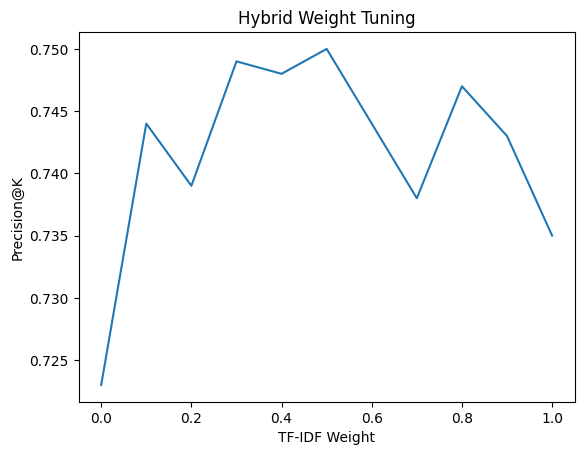

In [4]:
import matplotlib.pyplot as plt

weights = [w[0] for w in results]
scores = [w[2] for w in results]

plt.plot(weights, scores)
plt.xlabel("TF-IDF Weight")
plt.ylabel("Precision@K")
plt.title("Hybrid Weight Tuning")
plt.show()